# Day 40 : Structure ML Pipelines

---

## 📌 Objectives
- Learn how to structure Machine Learning Pipelines using Scikit-learn.
- Build an end-to-end supervised ML pipeline.
- Automate the entire ML workflow: preprocessing, training, and evaluation.
- Apply on a real-world dataset with classification objective.
- Use visualizations and metrics to evaluate pipeline performance.

---

**An end-to-end Machine Learning (ML) pipeline refers to the complete workflow of developing, deploying, and maintaining ML models—from data ingestion to model deployment and monitoring. Here's a detailed breakdown and a schematic diagram of a typical pipeline:**

#### 🔧 Components of an End-to-End ML Pipeline
1. Data Ingestion
Source: Databases (e.g., PostgreSQL, MongoDB), Data Warehouses (e.g., BigQuery, Redshift), APIs, Cloud Storage (e.g., AWS S3, GCP Storage).
Tools: Apache Airflow, AWS Glue, custom ETL scripts.
2. Data Preprocessing & Cleaning
Handle missing values, outliers, and data formatting.
Tools: Pandas, NumPy, PySpark (for big data), Scikit-learn transformers.
3. Feature Engineering
Creating meaningful features from raw data.
Tools: Scikit-learn Pipelines, Featuretools, custom transformations.
4. Model Selection & Training
Choose algorithms (e.g., Random Forest, XGBoost, Neural Networks).
Train and tune hyperparameters using:
GridSearchCV
Optuna
Bayesian Optimization
5. Model Evaluation
Use metrics like Accuracy, F1-score, RMSE, ROC-AUC.
Tools: Scikit-learn, Yellowbrick, SHAP for interpretability.
6. Model Deployment
Convert model to APIs or containers.
Tools:
Flask/FastAPI for REST APIs
Docker & Kubernetes for scalable deployment
Streamlit/Gradio for demos
7. Monitoring & Retraining
Track performance drift and retrain models.
Tools: MLflow, Prometheus + Grafana, custom dashboards.

---

# 1. Import Libraries

---

In [30]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, roc_curve, auc

---

## 2. Load Dataset

---

In [6]:
df = pd.read_csv('TelcoCustomerChurn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Exploration

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
#Drop customerID and handle TotalCharges
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [11]:
#Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
#Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

/Users/element/Desktop/ml_course/coursera_stanford/env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/lv/14jywzln6j74mk19cs9ymr2m0000gn/T/ipykernel_9011/950517448.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())


In [15]:
#Encode target variable
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

---

## 4. Define Features and target

---

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## 5. Split the data

---

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

## 6. Build Pipeline

---

In [23]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [24]:
#Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [25]:
#Full Pipeline with classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

---

## 7. Train the Pipeline

---

In [26]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

/Users/element/Desktop/ml_course/coursera_stanford/env/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['TotalCharges']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/element/Desktop/ml_course/coursera_stanford/env/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['TotalCharges']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 8. Evaluate the Pipeline

---

In [27]:
print('Classification Report:', classification_report(y_test, y_pred))
print('Confusion Matrix:', confusion_matrix(y_test, y_pred))
print('Accuracy Score:', accuracy_score(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Confusion Matrix: [[939  97]
 [155 218]]
Accuracy Score: 0.8211497515968772


## 9. Visualization

---

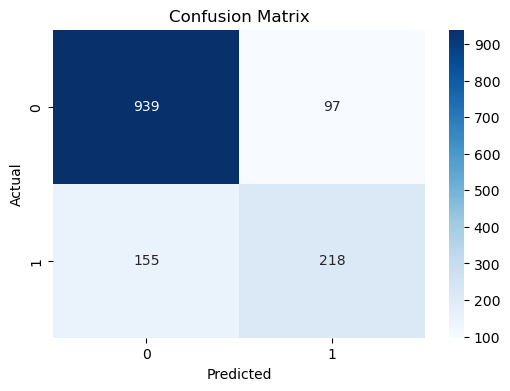

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [37]:
y_pred_proba = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

/Users/element/Desktop/ml_course/coursera_stanford/env/lib/python3.12/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['TotalCharges']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


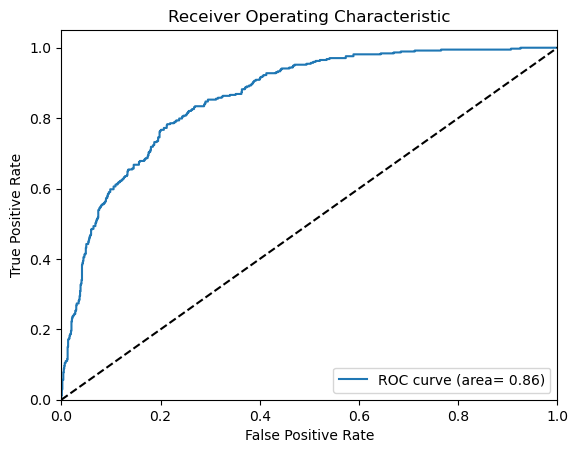

In [43]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area= {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## 10. Conclusion

---

- Built a Full ML pipeline using sci-kit learn
- Automated preprocessing for numeric and categorical variables
- Used Logistic Regression for churn classification
- Achieved performance evaluation with visual and metric outputs
